In [1]:
!pip install kagglehub

In [2]:
import kagglehub
import pandas as pd
import os

pd.set_option('display.max_columns', None)

# Download dataset
path = kagglehub.dataset_download("benroshan/factors-affecting-campus-placement")

print("Path dataset:", path)

# List contents of the downloaded directory to verify its structure
print("Contents of downloaded directory:", os.listdir(path))

# Load the single dataset file
df = pd.read_csv(os.path.join(path, "Placement_Data_Full_Class.csv"))

display(df.info())

Using Colab cache for faster access to the 'factors-affecting-campus-placement' dataset.
Path dataset: /kaggle/input/factors-affecting-campus-placement
Contents of downloaded directory: ['Placement_Data_Full_Class.csv']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    object 
 2   ssc_p           215 non-null    float64
 3   ssc_b           215 non-null    object 
 4   hsc_p           215 non-null    float64
 5   hsc_b           215 non-null    object 
 6   hsc_s           215 non-null    object 
 7   degree_p        215 non-null    float64
 8   degree_t        215 non-null    object 
 9   workex          215 non-null    object 
 10  etest_p         215 non-null    float64
 11  specialisation  215 non-null    object 
 12  mba_p           215 non-null    float64


None

# **1. Data Understanding**

In [3]:
df.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


In [4]:
# Numeric features
df.describe()

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
count,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,148.000000
mean,108.000000,67.303395,66.333163,66.370186,72.100558,62.278186,288655.405405
std,62.209324,10.827205,10.897509,7.358743,13.275956,5.833385,93457.452420
min,1.000000,40.890000,37.000000,50.000000,50.000000,51.210000,200000.000000
25%,54.500000,60.600000,60.900000,61.000000,60.000000,57.945000,240000.000000
50%,108.000000,67.000000,65.000000,66.000000,71.000000,62.000000,265000.000000
75%,161.500000,75.700000,73.000000,72.000000,83.500000,66.255000,300000.000000
max,215.000000,89.400000,97.700000,91.000000,98.000000,77.890000,940000.000000


In [5]:
# Categorical features
df.describe(include=['object'])

,gender,ssc_b,hsc_b,hsc_s,degree_t,workex,specialisation,status
count,215,215,215,215,215,215,215,215
unique,2,2,2,3,3,2,2,2
top,M,Central,Others,Commerce,Comm&Mgmt,No,Mkt&Fin,Placed
freq,139,116,131,113,145,141,120,148


In [6]:
# Count missing values
df.isnull().sum().to_frame().T

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,67


In [7]:
# Unique values per column
df.nunique().to_frame().T

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,215,2,103,2,97,2,3,89,3,2,100,2,205,2,45


# **2. Membersihkan Data**

In [8]:
# Imputasi nilai null ke 0 untuk salary, nilai null pada salary dikarenakan status = Not-Placed
df['salary'] = df['salary'].fillna(0)

# Count missing values
df.isnull().sum().to_frame().T

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


# **3. Mengkonstruksi Data**
- Encoding kolom kategorikal
- Scaling kolom numerik

In [9]:
# Identifikasi kolom numerik dan kategorikal
numerical_cols = df.select_dtypes(include="number").columns
categorical_cols = df.select_dtypes(include="object").columns

print("Numerical columns:", list(numerical_cols))
print("Categorical columns:", list(categorical_cols))

Numerical columns: ['sl_no', 'ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p', 'salary']
Categorical columns: ['gender', 'ssc_b', 'hsc_b', 'hsc_s', 'degree_t', 'workex', 'specialisation', 'status']


In [10]:
from sklearn.preprocessing import LabelEncoder

def encode_object_columns(df):
    """
    Encode all object-type columns in a DataFrame to integers.
    Returns a new DataFrame with encoded columns and a dictionary of encoders.
    """
    df_encoded = df.copy()  # don't override original
    le_dict = {}

    obj_cols = df_encoded.select_dtypes(include='object').columns
    for col in obj_cols:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col])
        le_dict[col] = le  # save encoder for inverse transform

    return df_encoded, le_dict

df, encoders = encode_object_columns(df)

display(df.head())

for col, encoder in encoders.items():
    print(f"Encoder for column '{col}': {encoder.classes_}")

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,1,67.00,1,91.00,1,1,58.00,2,0,55.0,1,58.80,1,270000.0
1,2,1,79.33,0,78.33,1,2,77.48,2,1,86.5,0,66.28,1,200000.0
2,3,1,65.00,0,68.00,0,0,64.00,0,0,75.0,0,57.80,1,250000.0
3,4,1,56.00,0,52.00,0,2,52.00,2,0,66.0,1,59.43,0,0.0
4,5,1,85.80,0,73.60,0,1,73.30,0,0,96.8,0,55.50,1,425000.0


Encoder for column 'gender': ['F' 'M']
Encoder for column 'ssc_b': ['Central' 'Others']
Encoder for column 'hsc_b': ['Central' 'Others']
Encoder for column 'hsc_s': ['Arts' 'Commerce' 'Science']
Encoder for column 'degree_t': ['Comm&Mgmt' 'Others' 'Sci&Tech']
Encoder for column 'workex': ['No' 'Yes']
Encoder for column 'specialisation': ['Mkt&Fin' 'Mkt&HR']
Encoder for column 'status': ['Not Placed' 'Placed']


In [11]:
from sklearn.preprocessing import MinMaxScaler

# 1. Normalisasi data
# Normalisasi dilakukan menggunakan MinMaxScaler untuk mengubah rentang nilai fitur menjadi 0-1.
scaler = MinMaxScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])
print("\nData setelah normalisasi:")
display(df.head())

# 2. Pemilihan fitur
X = df.drop('status', axis=1)
y = df['status']
print("\nFitur terpilih:", list(X.columns))


Data setelah normalisasi:


,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,0.000000,1,0.538240,1,0.889621,1,1,0.195122,2,0,0.104167,1,0.284483,1,0.287234
1,0.004673,1,0.792414,0,0.680890,1,2,0.670244,2,1,0.760417,0,0.564843,1,0.212766
2,0.009346,1,0.497011,0,0.510708,0,0,0.341463,0,0,0.520833,0,0.247001,1,0.265957
3,0.014019,1,0.311482,0,0.247117,0,2,0.048780,2,0,0.333333,1,0.308096,0,0.000000
4,0.018692,1,0.925788,0,0.602965,0,1,0.568293,0,0,0.975000,0,0.160795,1,0.452128



Fitur terpilih: ['sl_no', 'gender', 'ssc_p', 'ssc_b', 'hsc_p', 'hsc_b', 'hsc_s', 'degree_p', 'degree_t', 'workex', 'etest_p', 'specialisation', 'mba_p', 'salary']


# **4. Menentukan Label Data**

# **5. Visualiasasi Data**

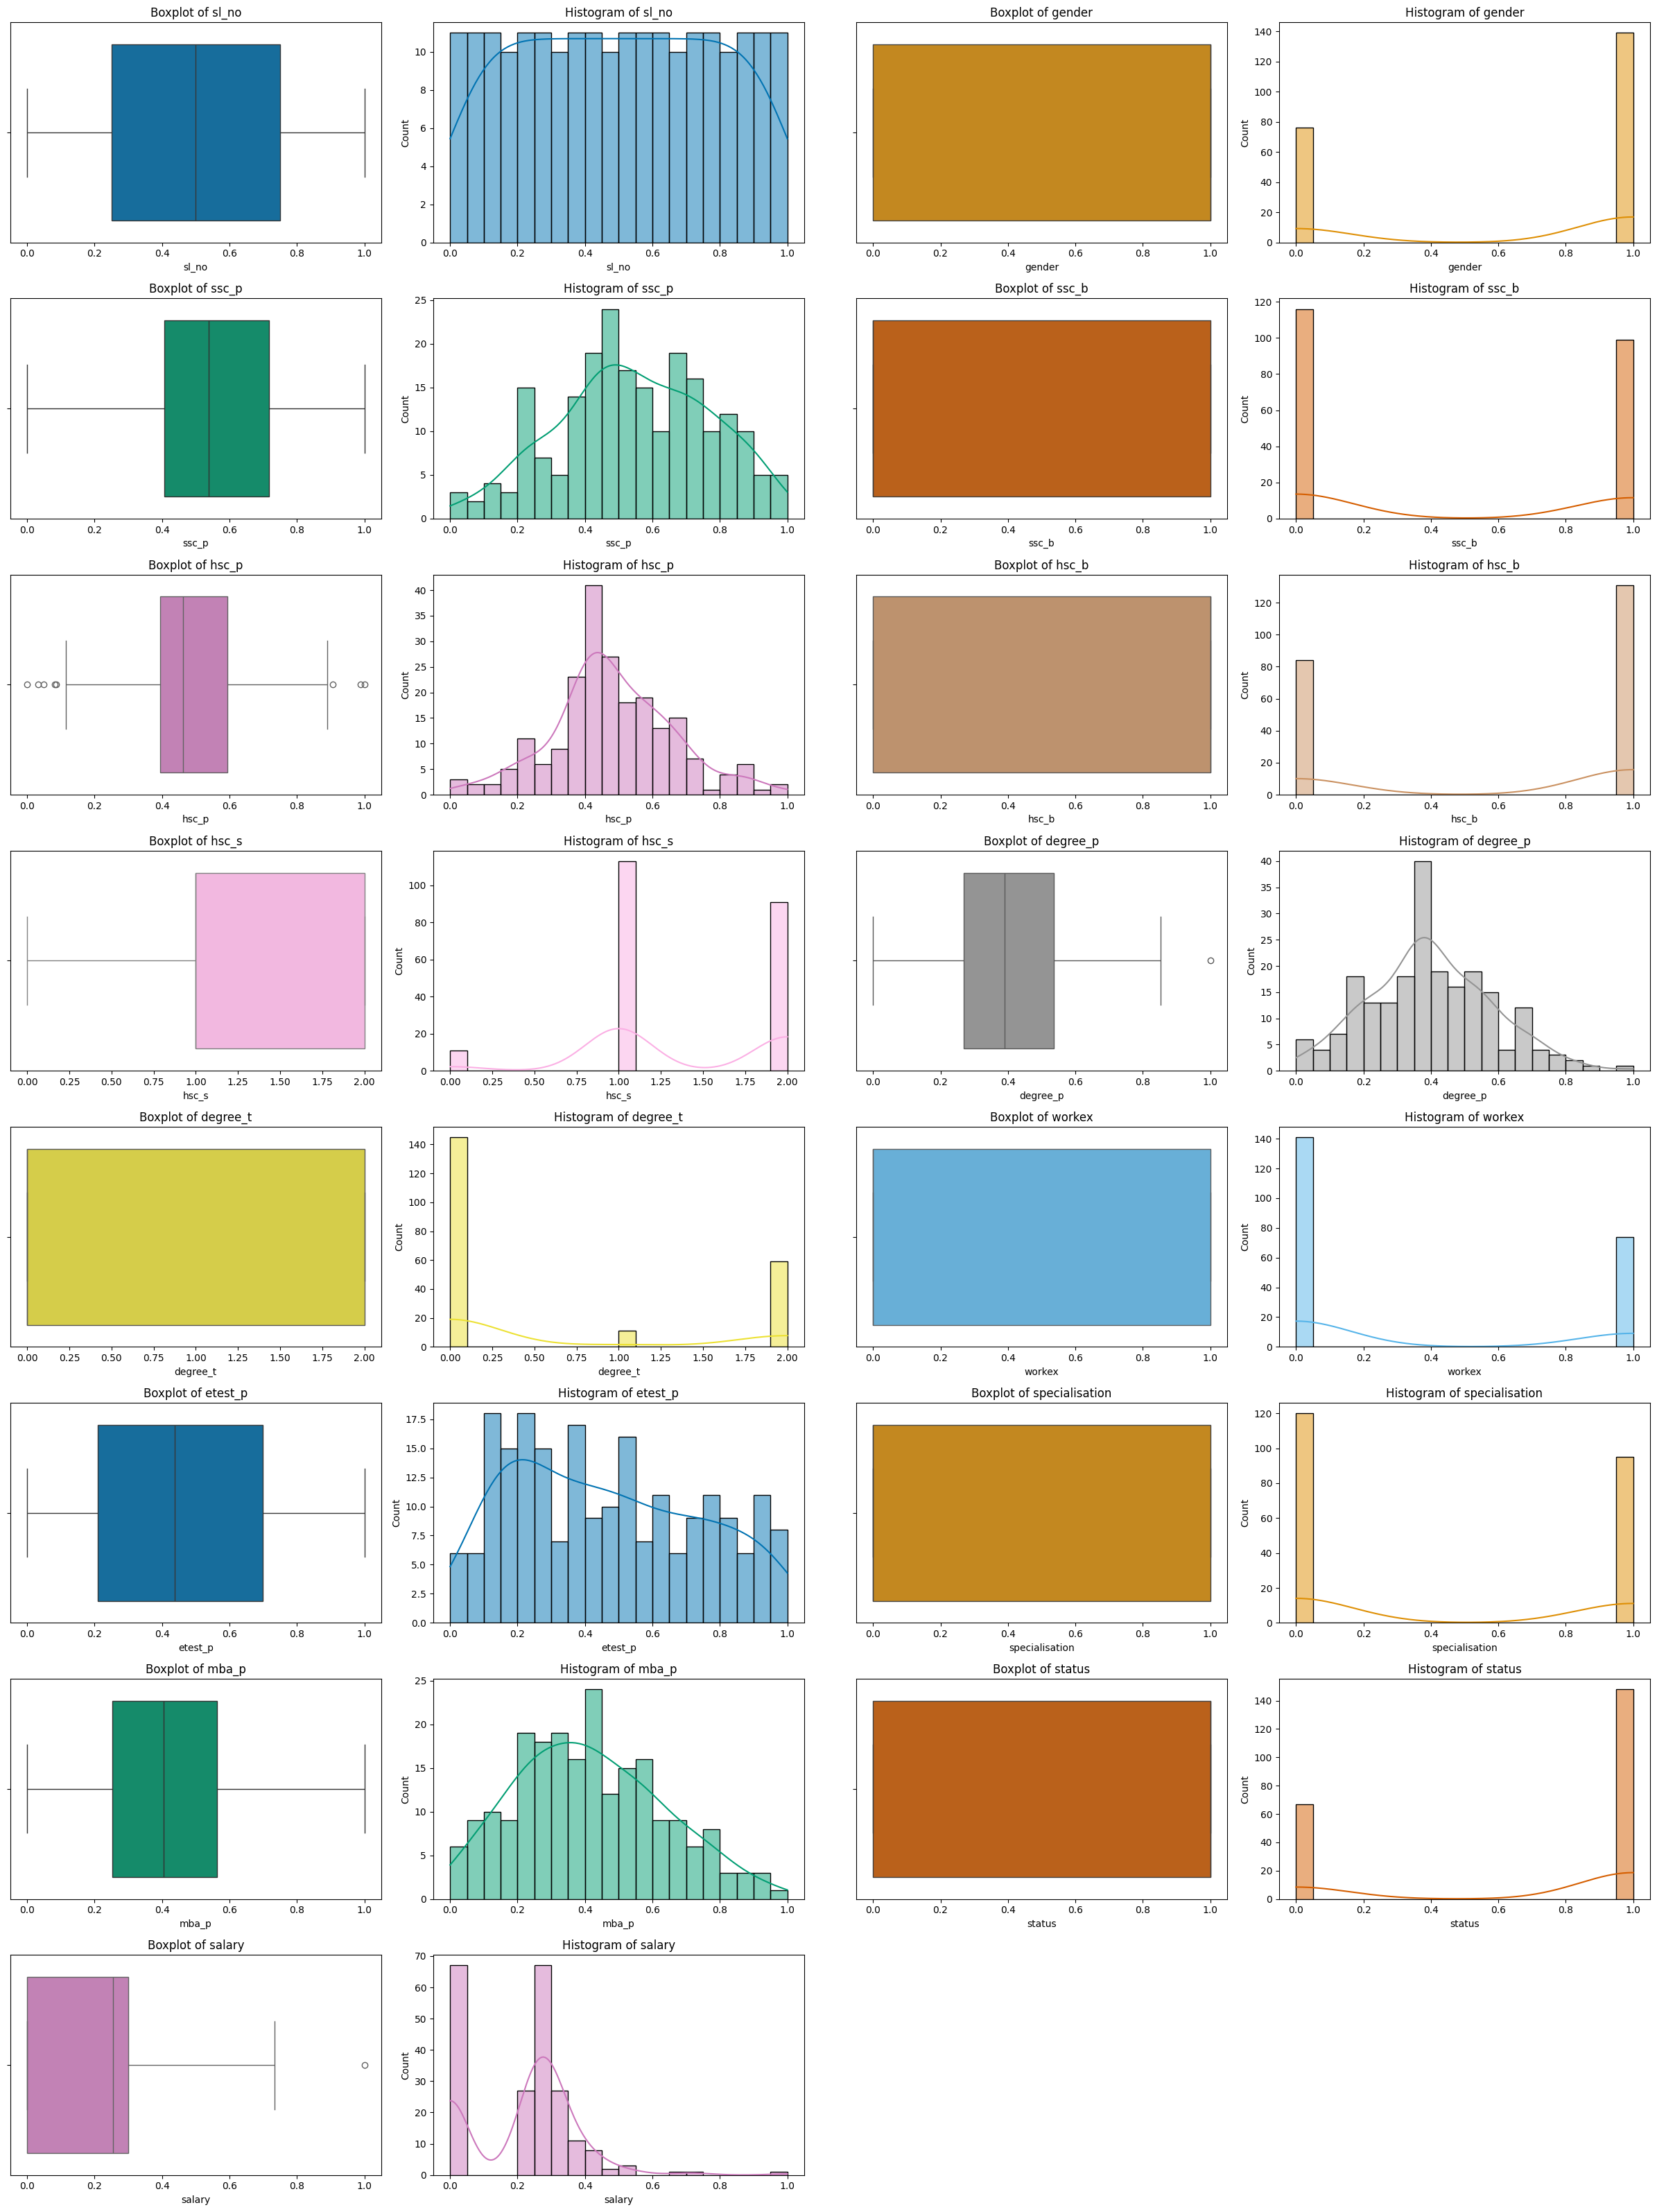

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select numeric columns
num_cols = df.select_dtypes(include=['int32', 'int64', 'float64', 'object']).columns

# Assign color palette
colors = sns.color_palette('colorblind', n_colors=len(num_cols))

# Each feature uses 2 columns (box + hist) → total cols = 4
ncols = 4
nrows = (len(num_cols) * 2 + ncols - 1) // ncols  # round up

fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows))
axes = axes.flatten()

plot_idx = 0
for col, color in zip(num_cols, colors):
    # Boxplot
    sns.boxplot(x=df[col], ax=axes[plot_idx], color=color)
    axes[plot_idx].set_title(f'Boxplot of {col}')
    plot_idx += 1

    # Histogram
    sns.histplot(df[col], bins=20, kde=True, ax=axes[plot_idx], color=color)
    axes[plot_idx].set_title(f'Histogram of {col}')
    plot_idx += 1

# Remove unused axes
for j in range(plot_idx, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

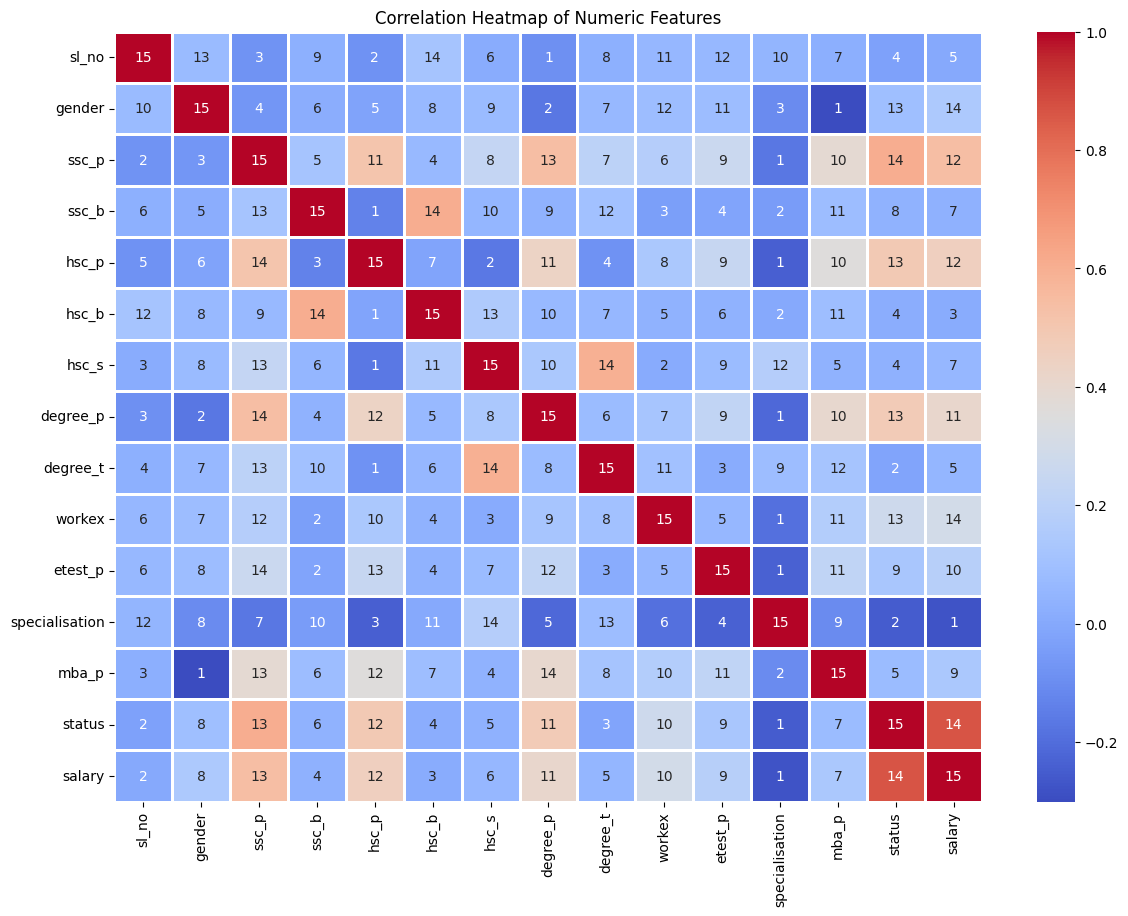

In [13]:
plt.figure(figsize=(14,10))
corr = df.select_dtypes(include=['float64','int64','int32']).corr()
sns.heatmap(corr, annot=corr.rank(axis='columns'), linewidth=1, cmap='coolwarm')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

Top correlated feature pairs:
 status  salary      0.865774
ssc_p   status      0.607889
ssc_b   hsc_b       0.605883
hsc_s   degree_t    0.596300
ssc_p   degree_p    0.538404
dtype: float64
Selected features for pairplot: ['salary', 'status', 'degree_p', 'hsc_b', 'degree_t', 'hsc_s', 'ssc_b', 'ssc_p']


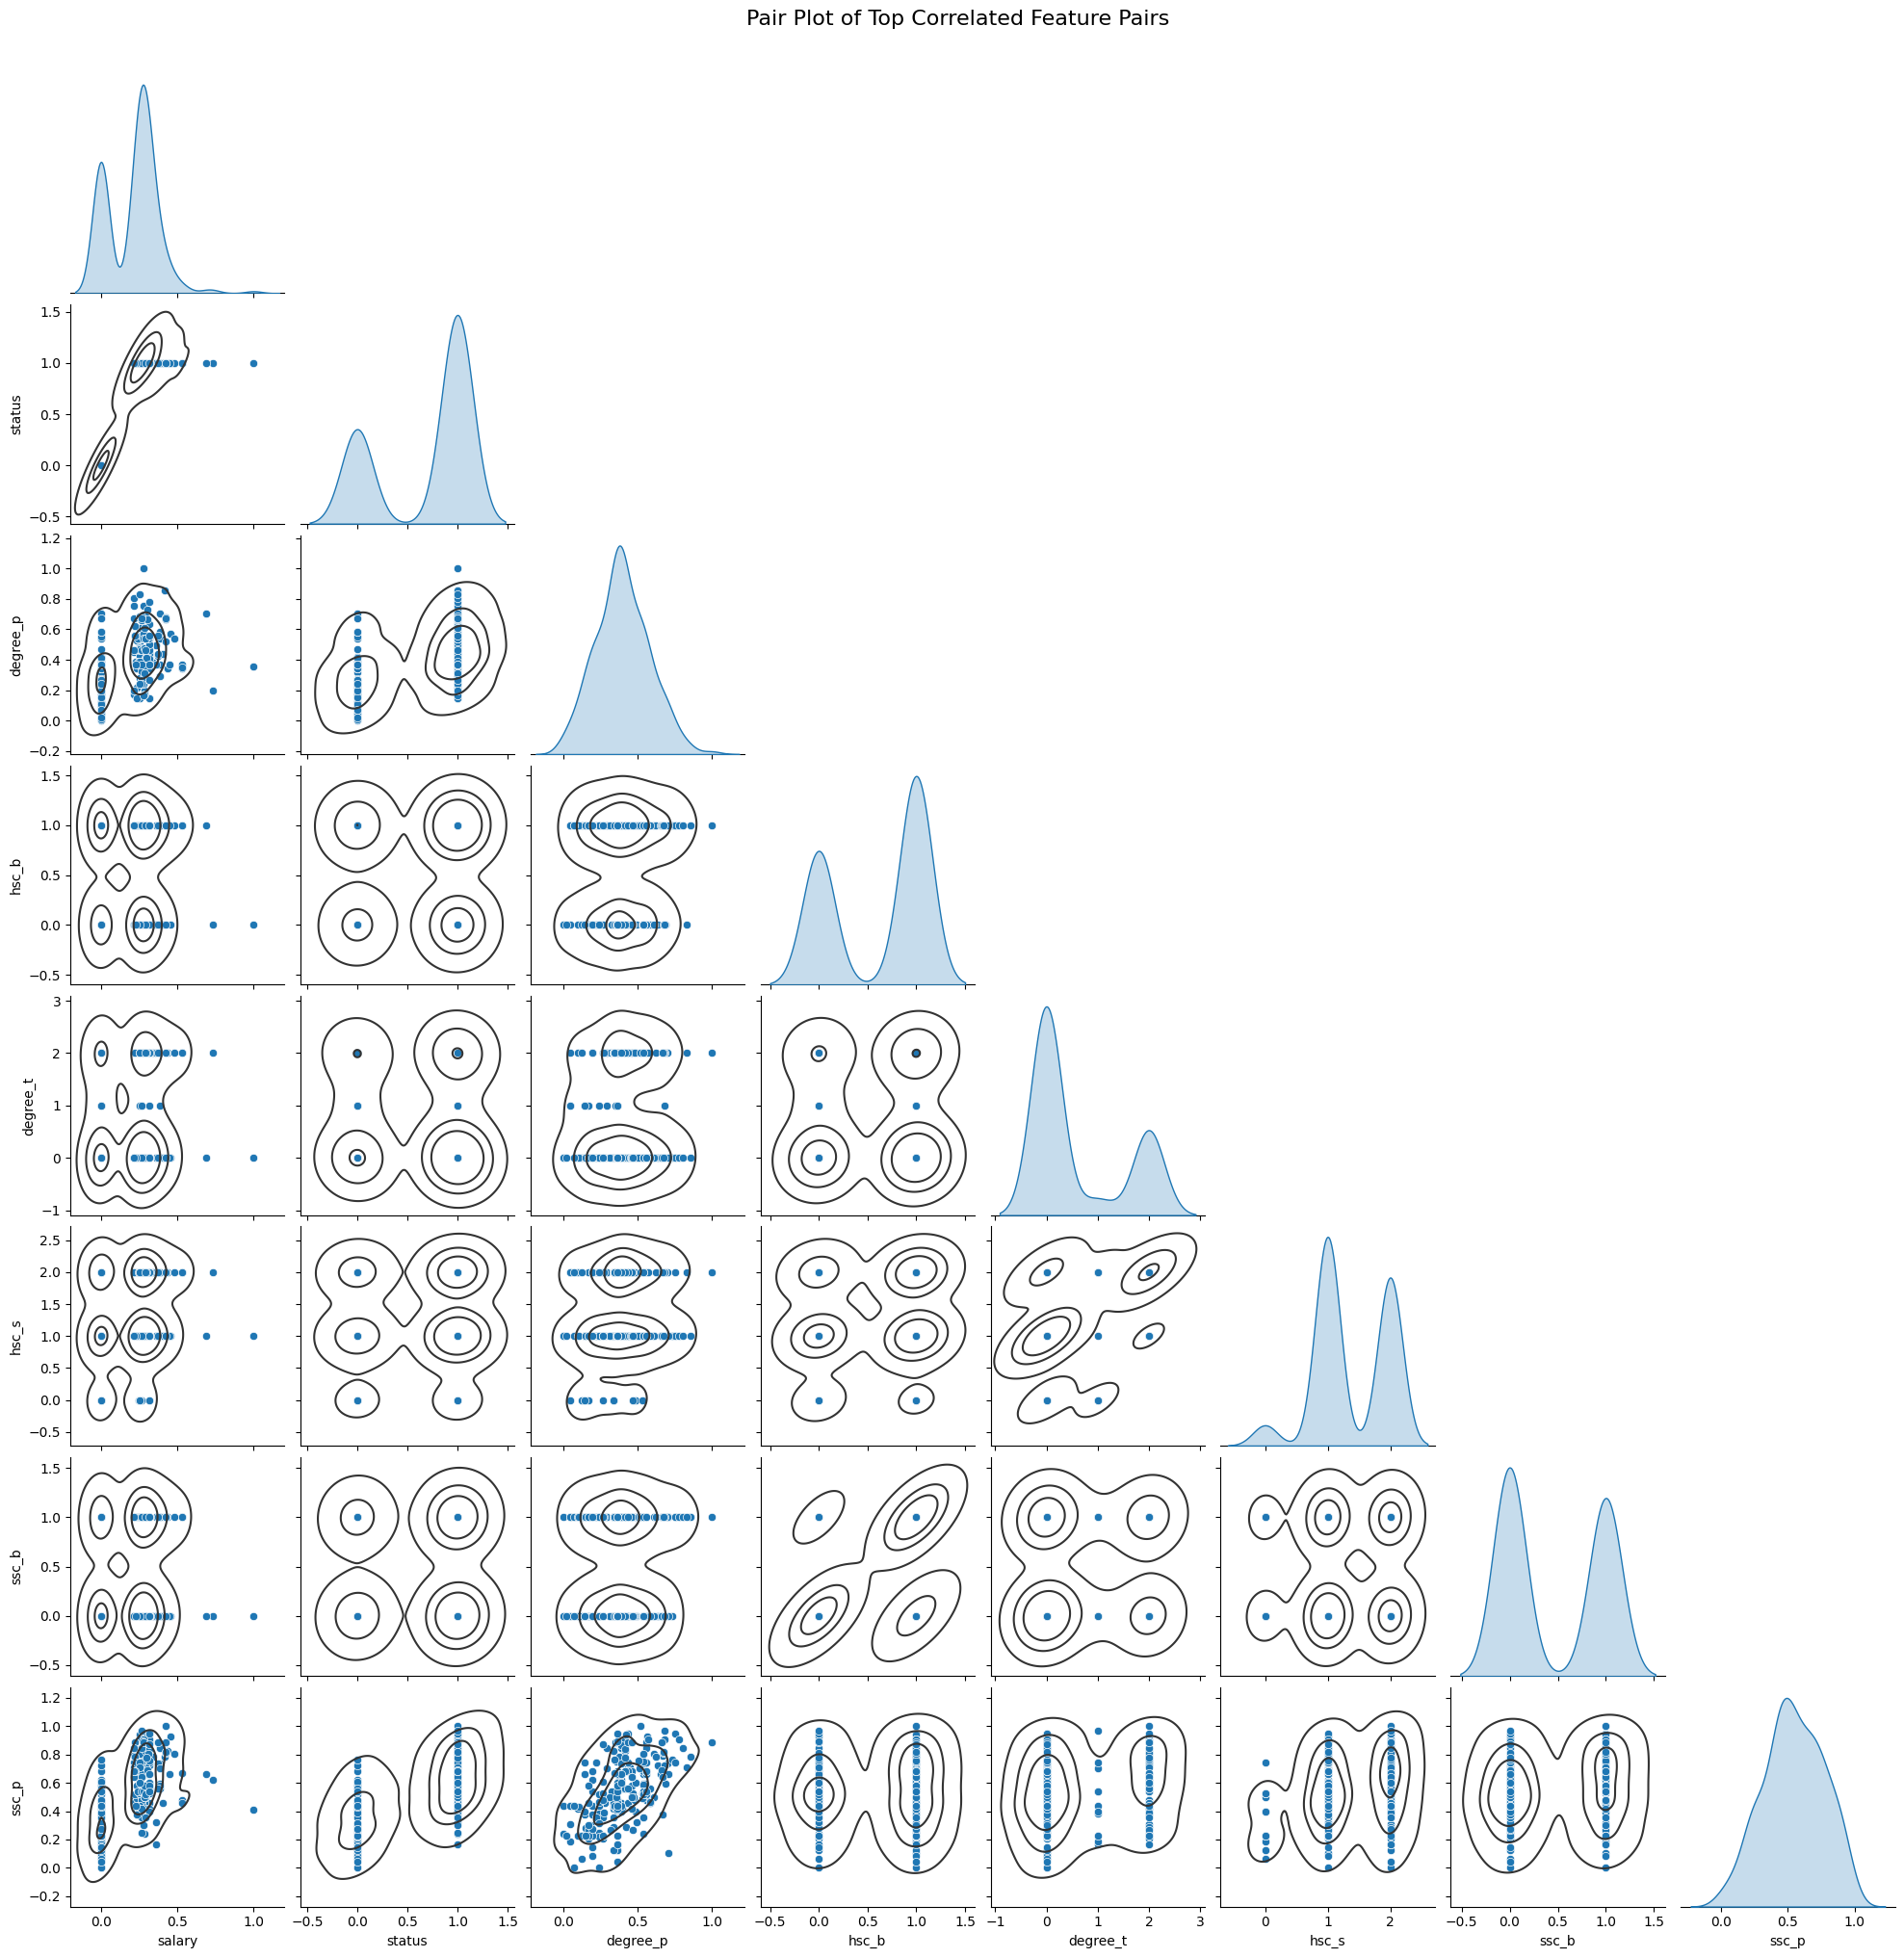

In [14]:
# --- Step 1: Compute correlation ---
corr = df.select_dtypes(include=['float64', 'int64', 'int32']).corr()

# --- Step 2: Find top N correlated pairs (excluding self-correlation) ---
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))  # upper triangle only
    .stack()
    .sort_values(ascending=False)
)

top_n = 5  # number of pairs
print("Top correlated feature pairs:\n", corr_pairs.head(top_n))

# --- Step 3: Extract unique feature names from these pairs ---
top_features = list(set([col for pair in corr_pairs.head(top_n).index for col in pair]))
print("Selected features for pairplot:", top_features)

# --- Step 4: Pairplot ---
g = sns.pairplot(df[top_features], diag_kind="kde", corner=True)
g.map_lower(sns.kdeplot, levels=4, color=".2")
plt.suptitle('Pair Plot of Top Correlated Feature Pairs', y=1.02, fontsize=16)
plt.show()

# **6. Evaluasi dan Dokumentasi**

In [15]:
df.describe()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
count,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000
mean,0.500000,0.646512,0.544494,0.460465,0.483248,0.609302,1.372093,0.399273,0.600000,0.344186,0.460428,0.441860,0.414850,0.688372,0.211385
std,0.290698,0.479168,0.223195,0.499598,0.179531,0.489045,0.580978,0.179482,0.890238,0.476211,0.276582,0.497767,0.218643,0.464240,0.164661
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.250000,0.000000,0.406308,0.000000,0.393740,0.000000,1.000000,0.268293,0.000000,0.000000,0.208333,0.000000,0.252436,0.000000,0.000000
50%,0.500000,1.000000,0.538240,0.000000,0.461285,1.000000,1.000000,0.390244,0.000000,0.000000,0.437500,0.000000,0.404423,1.000000,0.255319
75%,0.750000,1.000000,0.717584,1.000000,0.593081,1.000000,2.000000,0.536585,2.000000,1.000000,0.697917,1.000000,0.563906,1.000000,0.300532
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
